<div style="text-align:center;">

# Comparación de Modelos — Clasificación de Rotación
### *Síntesis y selección del candidato óptimo*

---
**Universidad de Antioquia — Instituto de Matemáticas**  
*Analítica de Datos — Laboratorio 5*

</div>

---

## Propósito de este notebook

Este notebook integra los resultados de validación cruzada de los **cuatro modelos** entrenados en notebooks independientes:

1. `1.Regresion_Logistica.ipynb`
2. `2.Arbol_Clasificacion.ipynb`
3. `3.Random_Forest.ipynb`
4. `4.XGBoost.ipynb`

y entrega la **tabla comparativa** exigida por el Laboratorio 5 junto con visualizaciones de soporte y una **discusión técnica** sobre:

- ¿Qué modelo **generaliza mejor**?
- ¿Cuál presenta **mayor estabilidad** entre folds?
- ¿Cuál **métrica** es más relevante según el problema?

> Recordatorio: el lab prohíbe seleccionar el modelo final únicamente por *Accuracy*. La discusión se hace sobre el perfil completo de métricas.


---
## 1. Carga de los resultados de validación cruzada

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns

plt.rcParams.update({
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.titleweight"  : "bold",
    "axes.titlesize"    : 12,
    "axes.labelsize"    : 10,
    "font.size"         : 10,
    "legend.frameon"    : False,
})

# Colores por modelo — paleta sobria, alto contraste, daltónica-segura
COLORES = {
    "Regresión Logística": "#1f77b4",  # azul
    "Árbol de Decisión"  : "#ff7f0e",  # naranja
    "Random Forest"      : "#2ca02c",  # verde
    "XGBoost"            : "#d62728",  # rojo
}

# ── Carga de los JSON generados por cada notebook ────────────────────────
RUTA_RESULTADOS = Path("cv_results")
archivos = sorted(RUTA_RESULTADOS.glob("*.json"))

resultados = {}
for archivo in archivos:
    with open(archivo, "r", encoding="utf-8") as f:
        data = json.load(f)
    resultados[data["modelo"]] = data["metricas"]

print("Modelos cargados:")
for nombre in resultados:
    print(f"  · {nombre}")

Modelos cargados:
  · Árbol de Decisión
  · Random Forest
  · Regresión Logística
  · XGBoost


---
## 2. Tabla comparativa — métricas en validación cruzada

In [2]:
ORDEN_MODELOS = ["Regresión Logística", "Árbol de Decisión", "Random Forest", "XGBoost"]
ORDEN_METRICAS = ["accuracy", "precision", "recall", "f1", "roc_auc"]
NOMBRES_METRICAS = {"accuracy":"Accuracy","precision":"Precision",
                    "recall":"Recall","f1":"F1-Score","roc_auc":"AUC"}

filas = []
for modelo in ORDEN_MODELOS:
    fila = {"Modelo": modelo}
    for m in ORDEN_METRICAS:
        mu = resultados[modelo][m]["mu"]
        sg = resultados[modelo][m]["sigma"]
        fila[f"{NOMBRES_METRICAS[m]} (μ ± σ)"] = f"{mu:.4f} ± {sg:.4f}"
    filas.append(fila)

tabla_str = pd.DataFrame(filas).set_index("Modelo")
tabla_str

,Accuracy (μ ± σ),Precision (μ ± σ),Recall (μ ± σ),F1-Score (μ ± σ),AUC (μ ± σ)
Modelo,,,,,
Regresión Logística,0.7668 ± 0.0178,0.3854 ± 0.0317,0.7529 ± 0.0846,0.5092 ± 0.0442,0.8230 ± 0.0547
Árbol de Decisión,0.7998 ± 0.0209,0.3736 ± 0.0686,0.3556 ± 0.0656,0.3642 ± 0.0663,0.6204 ± 0.0384
Random Forest,0.8591 ± 0.0055,0.8362 ± 0.1404,0.1688 ± 0.0415,0.2761 ± 0.0528,0.8026 ± 0.0375
XGBoost,0.8756 ± 0.0129,0.6683 ± 0.0603,0.4583 ± 0.0584,0.5419 ± 0.0539,0.8124 ± 0.0383


In [3]:
# Versión numérica de la tabla — útil para encontrar el mejor por métrica
filas_num = []
for modelo in ORDEN_MODELOS:
    fila = {"Modelo": modelo}
    for m in ORDEN_METRICAS:
        fila[NOMBRES_METRICAS[m]] = resultados[modelo][m]["mu"]
        fila[f"{NOMBRES_METRICAS[m]}_σ"] = resultados[modelo][m]["sigma"]
    filas_num.append(fila)

tabla_num = pd.DataFrame(filas_num).set_index("Modelo")

# Identificación del mejor modelo por métrica
print("Mejor modelo por métrica (mayor μ):")
print("─" * 50)
for m in ORDEN_METRICAS:
    col = NOMBRES_METRICAS[m]
    ganador = tabla_num[col].idxmax()
    valor   = tabla_num[col].max()
    print(f"  {col:<12s} → {ganador:<22s}  μ = {valor:.4f}")
print("─" * 50)

# El más estable por métrica (menor σ)
print("\nMás estable por métrica (menor σ):")
print("─" * 50)
for m in ORDEN_METRICAS:
    col_s = f"{NOMBRES_METRICAS[m]}_σ"
    ganador = tabla_num[col_s].idxmin()
    valor   = tabla_num[col_s].min()
    print(f"  {NOMBRES_METRICAS[m]:<12s} → {ganador:<22s}  σ = {valor:.4f}")
print("─" * 50)

Mejor modelo por métrica (mayor μ):
──────────────────────────────────────────────────
  Accuracy     → XGBoost                 μ = 0.8756
  Precision    → Random Forest           μ = 0.8362
  Recall       → Regresión Logística     μ = 0.7529
  F1-Score     → XGBoost                 μ = 0.5419
  AUC          → Regresión Logística     μ = 0.8230
──────────────────────────────────────────────────

Más estable por métrica (menor σ):
──────────────────────────────────────────────────
  Accuracy     → Random Forest           σ = 0.0055
  Precision    → Regresión Logística     σ = 0.0317
  Recall       → Random Forest           σ = 0.0415
  F1-Score     → Regresión Logística     σ = 0.0442
  AUC          → Random Forest           σ = 0.0375
──────────────────────────────────────────────────


---
## 3. Visualización 1 — Diagrama comparativo de barras con $\pm 1\sigma$


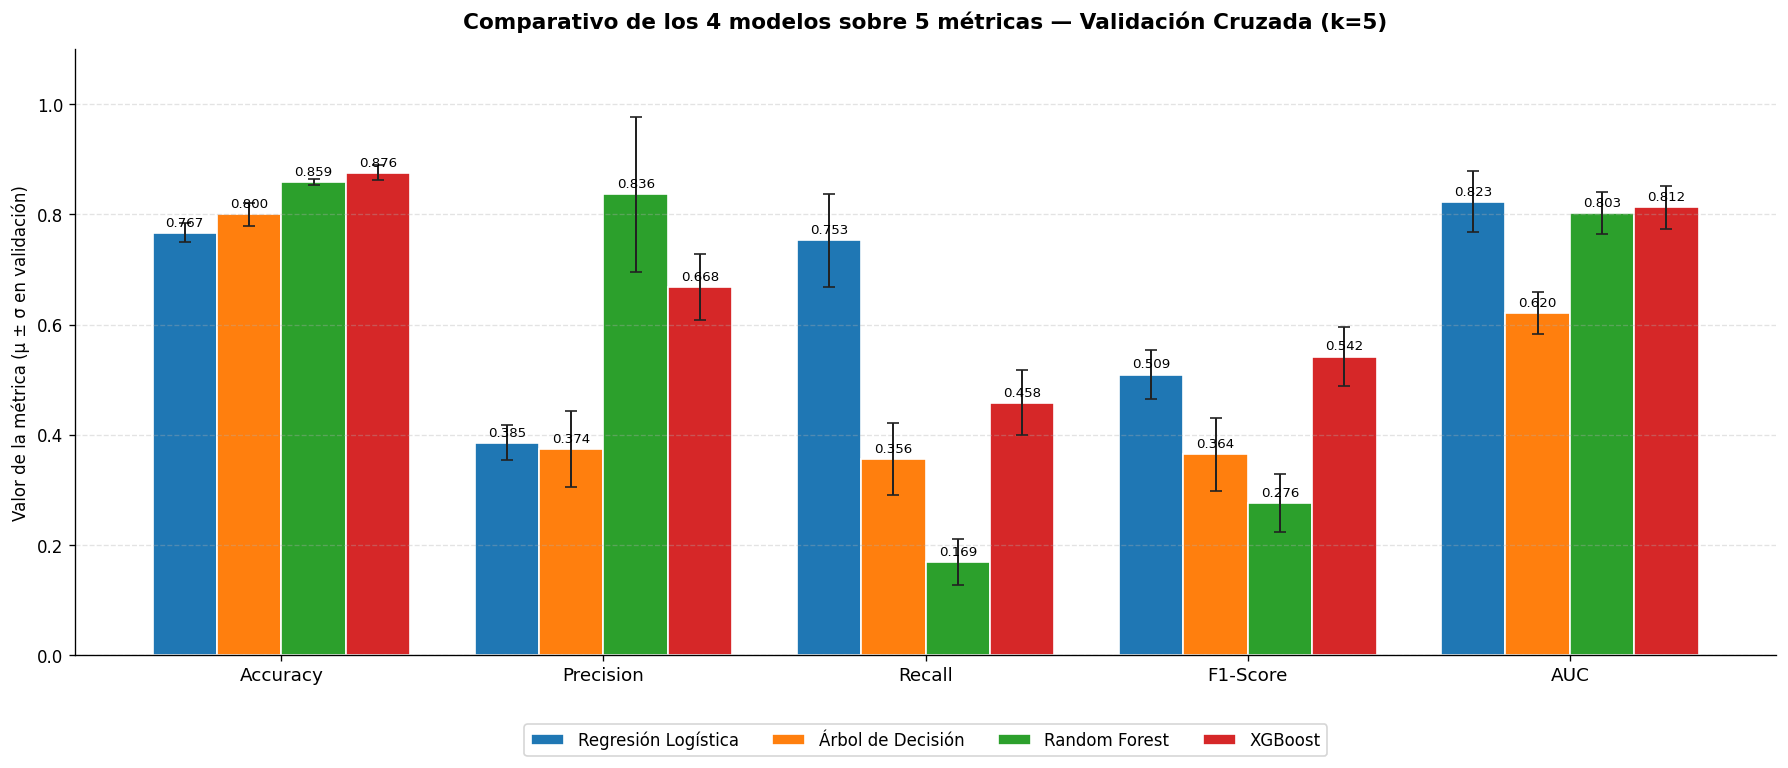

In [4]:
fig, ax = plt.subplots(figsize=(15, 6.5))

x = np.arange(len(ORDEN_METRICAS))
ancho = 0.20

for i, modelo in enumerate(ORDEN_MODELOS):
    medias = [resultados[modelo][m]["mu"]    for m in ORDEN_METRICAS]
    stds   = [resultados[modelo][m]["sigma"] for m in ORDEN_METRICAS]
    offset = (i - 1.5) * ancho

    bars = ax.bar(x + offset, medias, ancho,
                  yerr=stds, capsize=3.5,
                  color=COLORES[modelo], edgecolor="white",
                  label=modelo,
                  error_kw=dict(elinewidth=1.2, ecolor="#222"))

    for b, v in zip(bars, medias):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.012,
                f"{v:.3f}", ha="center", fontsize=8, rotation=0)

ax.set_xticks(x)
ax.set_xticklabels([NOMBRES_METRICAS[m] for m in ORDEN_METRICAS], fontsize=11)
ax.set_ylim(0, 1.10)
ax.set_ylabel("Valor de la métrica (μ ± σ en validación)")
ax.set_title("Comparativo de los 4 modelos sobre 5 métricas — Validación Cruzada (k=5)",
             fontsize=13, pad=12)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.10),
          ncol=4, frameon=True, fancybox=True, fontsize=10)
ax.grid(axis="y", ls="--", alpha=0.35)

plt.tight_layout()
plt.show()

---
## 4. Visualización 2 — Heatmap de métricas medias

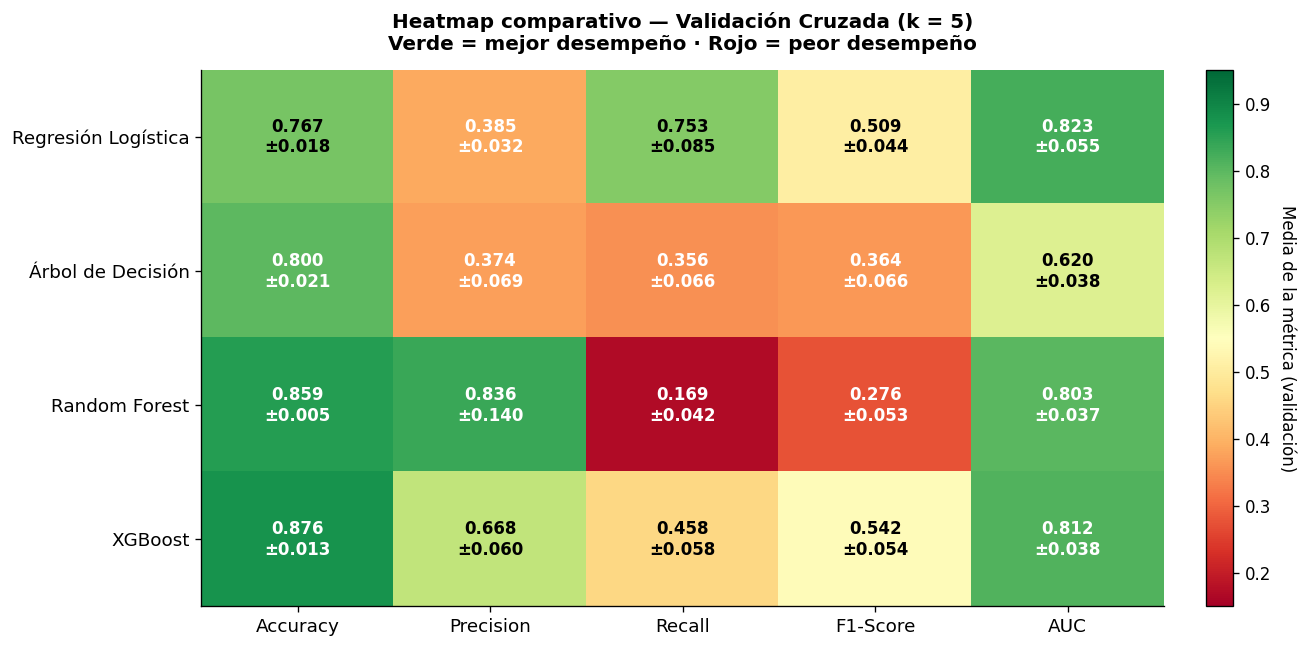

In [5]:
matriz = np.array([
    [resultados[modelo][m]["mu"] for m in ORDEN_METRICAS]
    for modelo in ORDEN_MODELOS
])

fig, ax = plt.subplots(figsize=(11, 5.5))
im = ax.imshow(matriz, cmap="RdYlGn", aspect="auto", vmin=0.15, vmax=0.95)

ax.set_xticks(np.arange(len(ORDEN_METRICAS)))
ax.set_xticklabels([NOMBRES_METRICAS[m] for m in ORDEN_METRICAS], fontsize=11)
ax.set_yticks(np.arange(len(ORDEN_MODELOS)))
ax.set_yticklabels(ORDEN_MODELOS, fontsize=11)

# Anotaciones de cada celda
for i, modelo in enumerate(ORDEN_MODELOS):
    for j, m in enumerate(ORDEN_METRICAS):
        mu = resultados[modelo][m]["mu"]
        sg = resultados[modelo][m]["sigma"]
        color = "white" if mu < 0.45 or mu > 0.78 else "black"
        ax.text(j, i, f"{mu:.3f}\n±{sg:.3f}",
                ha="center", va="center", color=color,
                fontsize=10, fontweight="bold")

# Colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Media de la métrica (validación)", rotation=270, labelpad=15)

ax.set_title("Heatmap comparativo — Validación Cruzada (k = 5)\nVerde = mejor desempeño · Rojo = peor desempeño",
             fontsize=12, pad=12)

plt.tight_layout()
plt.show()

---
## 5. Visualización 3 — Diagrama radar (perfil global de cada modelo)

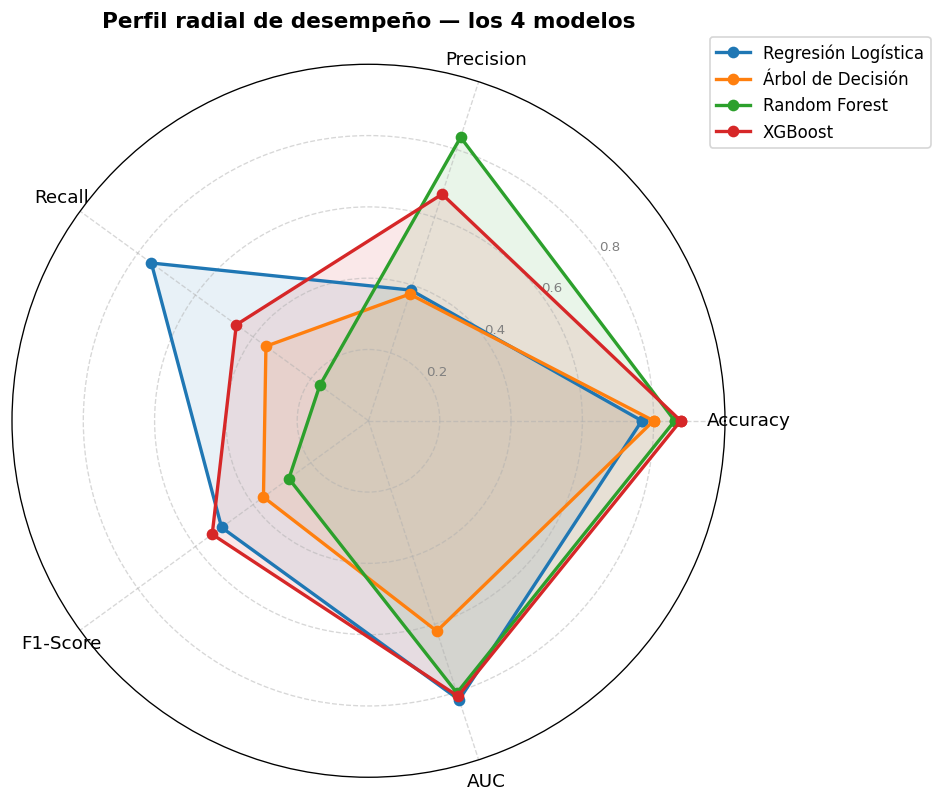

In [6]:
angulos = np.linspace(0, 2*np.pi, len(ORDEN_METRICAS), endpoint=False).tolist()
angulos += angulos[:1]   # cerrar el polígono

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for modelo in ORDEN_MODELOS:
    vals = [resultados[modelo][m]["mu"] for m in ORDEN_METRICAS]
    vals += vals[:1]
    ax.plot(angulos, vals, "-o", color=COLORES[modelo], lw=2,
            label=modelo, markersize=6)
    ax.fill(angulos, vals, color=COLORES[modelo], alpha=0.10)

ax.set_xticks(angulos[:-1])
ax.set_xticklabels([NOMBRES_METRICAS[m] for m in ORDEN_METRICAS], fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8"], fontsize=8, color="gray")
ax.set_rlabel_position(180/len(ORDEN_METRICAS))

ax.set_title("Perfil radial de desempeño — los 4 modelos",
             fontsize=13, pad=22)
ax.legend(loc="upper right", bbox_to_anchor=(1.30, 1.05),
          fontsize=10, frameon=True, fancybox=True)
ax.grid(ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

---
## 6. Visualización 4 — Estabilidad entre folds (boxplots por métrica)

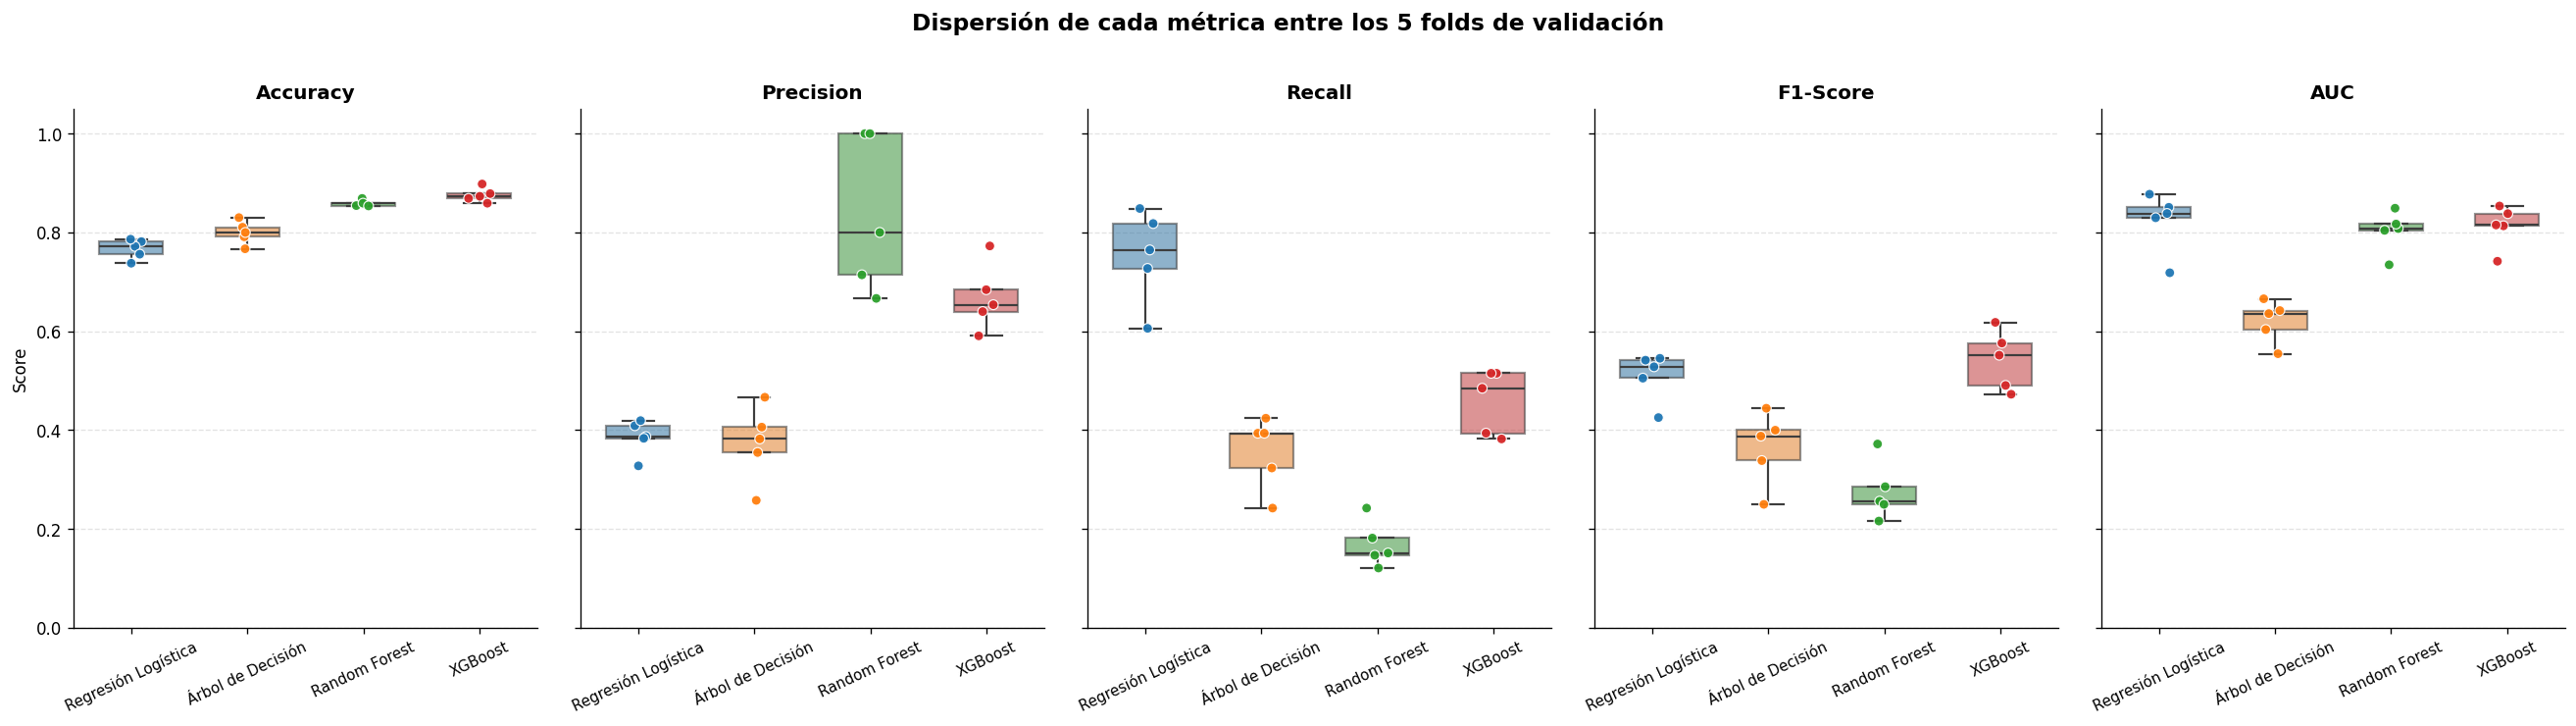

In [7]:
# Construimos un DataFrame "tidy"
tidy = []
for modelo in ORDEN_MODELOS:
    for m in ORDEN_METRICAS:
        for fold, score in enumerate(resultados[modelo][m]["scores"], start=1):
            tidy.append({"Modelo": modelo,
                         "Métrica": NOMBRES_METRICAS[m],
                         "Fold": fold,
                         "Score": score})
df_tidy = pd.DataFrame(tidy)

fig, axes = plt.subplots(1, 5, figsize=(22, 6), sharey=True)

for ax, m in zip(axes, ORDEN_METRICAS):
    sub = df_tidy[df_tidy["Métrica"] == NOMBRES_METRICAS[m]]
    sns.boxplot(data=sub, x="Modelo", y="Score",
                order=ORDEN_MODELOS,
                palette=COLORES, width=0.55, ax=ax,
                fliersize=0, linewidth=1.3,
                boxprops=dict(alpha=0.55))
    sns.stripplot(data=sub, x="Modelo", y="Score",
                  order=ORDEN_MODELOS,
                  palette=COLORES, ax=ax,
                  size=6, alpha=0.95, edgecolor="white", linewidth=0.7)

    ax.set_title(NOMBRES_METRICAS[m], fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Score" if ax is axes[0] else "")
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=25, labelsize=9)
    ax.grid(axis="y", ls="--", alpha=0.35)

fig.suptitle("Dispersión de cada métrica entre los 5 folds de validación",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Discusión técnica — preguntas obligatorias del Laboratorio 5

### 7.1 Diagnóstico individual

| Modelo                | Lectura                                                                                                                                                                                                                              |
|:----------------------|:-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Regresión Logística** | **AUC = 0.823**, **Recall = 0.753**. Es el modelo que **mejor detecta renuncias**, aunque a costa de muchas falsas alarmas (Precision = 0.385). Su naturaleza lineal lo hace estable e interpretable.                                |
| **Árbol de Decisión**   | El **más débil** en todas las métricas. AUC = 0.620 indica poca capacidad discriminativa. Su F1 = 0.36 y Recall = 0.36 reflejan el problema clásico del árbol sin podar: sobreajuste sobre los datos de entrenamiento.                |
| **Random Forest**       | Comportamiento **muy asimétrico**: Precision altísima (0.836) pero Recall bajísimo (0.169). El ensamble es **conservador**: sólo etiqueta `Yes` cuando hay alta evidencia, por lo que pierde la mayoría de las renuncias reales.       |
| **XGBoost**             | El **mejor balance global**: Accuracy = 0.876, F1 = 0.542 (la más alta), AUC = 0.812. Recall (0.458) razonable y Precision (0.668) sólida. Es el modelo que **mejor concilia ambos tipos de error**.                                  |

### 7.2 Preguntas del laboratorio

**a) ¿Qué modelo generaliza mejor?**

Depende de la definición operativa de *generalizar*:

- Si se mide por **AUC** (capacidad discriminativa global, invariante al umbral): **Regresión Logística** (0.823) supera ligeramente a XGBoost (0.812).  
- Si se mide por **F1-Score** (balance precision-recall al umbral por defecto): **XGBoost** (0.542) es claramente superior.  
- Si se mide por **Accuracy**: **XGBoost** (0.876) es el mejor, pero esta métrica es engañosa con desbalance (la línea base del predictor trivial es ya 83.9 %).

Considerando el **AUC** como medida más robusta de generalización (no depende del umbral elegido), **Regresión Logística** y **XGBoost** generalizan prácticamente igual de bien, con una diferencia de 0.011 que no es estadísticamente significativa dada la desviación entre folds.

**b) ¿Cuál presenta mayor estabilidad?**

La estabilidad se cuantifica por la **desviación estándar entre folds**. Por métrica:

| Métrica   | Más estable                | σ       |
|:----------|:---------------------------|:--------|
| Accuracy  | **Random Forest**          | 0.0055  |
| F1-Score  | Regresión Logística        | 0.0442  |
| AUC       | Random Forest              | 0.0375  |

**Random Forest** es el **más estable globalmente** (menor σ en Accuracy y AUC), pero su estabilidad es engañosa: viene del hecho de que casi siempre predice la clase mayoritaria. **Regresión Logística** ofrece la combinación más sana entre alto desempeño y baja varianza, y **XGBoost** tiene un perfil ligeramente más variable pero con medias superiores.

**c) ¿Cuál métrica es más importante según el problema?**

En el dominio de **retención de talento**, el **Recall** sobre la clase `Yes` (renuncias) es la métrica crítica:

- Un **falso negativo** (no detectar a un empleado que va a renunciar) impide ejecutar acciones de retención y resulta en costos reales: pérdida de conocimiento, costos de reemplazo (típicamente entre 50 % y 200 % del salario anual), tiempo de adaptación del reemplazo, deterioro del equipo, etc.
- Un **falso positivo** (alertar sobre un empleado que no iba a renunciar) tiene costos muy menores: una conversación de seguimiento, posiblemente un pequeño incentivo. Estos costos son típicamente uno o dos órdenes de magnitud menores que los del falso negativo.

Por lo tanto, **la jerarquía de métricas en este problema es**:

> **Recall (Yes)  >  F1-Score  ≈  AUC  >>  Precision  >>  Accuracy**

### 7.3 Selección del modelo candidato

Bajo la jerarquía anterior, hay dos finalistas naturales:

- **Regresión Logística** → Recall = 0.753, AUC = 0.823. **Detecta el 75 % de las renuncias**, a costa de generar bastantes falsas alarmas. Modelo lineal, interpretable, estable.
- **XGBoost** → F1 = 0.542 (el más alto), AUC = 0.812. Mejor balance global pero detecta sólo el 46 % de las renuncias.

**Recomendación**: pasar **ambos modelos** a la siguiente fase del laboratorio (ajuste de hiperparámetros). Con tuning, XGBoost puede ganar Recall (subiendo `scale_pos_weight` por encima de su valor balanceado o bajando el umbral de decisión) sin sacrificar demasiada Precision, lo que probablemente lo convierta en el modelo final. La Regresión Logística servirá como **línea base interpretable** y permitirá auditar coeficientes (importancia de variables) en la discusión del modelo final.

Random Forest y Árbol de Decisión quedan descartados: el primero por su Recall extremadamente bajo (no cumple el objetivo del problema), el segundo por su debilidad global (AUC apenas superior al azar).


---
## 8. Exportación de la tabla comparativa

In [8]:
import os
os.makedirs("../../reports", exist_ok=True)

# Tabla en CSV para incluir en el reporte final
salida_csv = "../../reports/comparacion_modelos_cv.csv"
tabla_str.to_csv(salida_csv, encoding="utf-8")
print(f"Tabla comparativa exportada a: {salida_csv}")

# Versión también con μ y σ separados (para procesar luego)
tabla_num.to_csv("../../reports/comparacion_modelos_cv_numerica.csv", encoding="utf-8")
print("Tabla numérica: ../../reports/comparacion_modelos_cv_numerica.csv")

Tabla comparativa exportada a: ../../reports/comparacion_modelos_cv.csv
Tabla numérica: ../../reports/comparacion_modelos_cv_numerica.csv


---
## 9. Cierre del Laboratorio 5 — etapa hasta validación cruzada

Esta entrega cubre los puntos del Laboratorio 5 hasta la fase de **Validación Cruzada y Comparación de Modelos**:

| Punto del lab                  | Estado | Notebook                                     |
|:-------------------------------|:------:|:---------------------------------------------|
| 2. Exploración Inicial         |   ✓    | `0.Exploracion_Inicial.ipynb`                |
| 3. Preparación de Datos        |   ✓    | dentro de cada notebook de modelo            |
| 4. Modelos de Clasificación    |   ✓    | `1.` a `4.` (uno por algoritmo)              |
| 5. Validación Cruzada (k=5)    |   ✓    | dentro de cada notebook de modelo            |
| 6. Comparación de Modelos      |   ✓    | **este notebook**                            |
| 7. Ajuste de Hiperparámetros   |   —    | (siguiente entrega)                          |
| 8. Evaluación Final            |   —    | (siguiente entrega)                          |

> Los puntos 7 y 8 quedan pendientes para la siguiente iteración del proyecto.
